# Beyond tiles: free-form still-life portraits — a guided tour

The rest of this repository builds mosaics from a fixed vocabulary of
still-life *tiles*. This notebook drops the vocabulary: a constraint solver
places **every cell individually**, subject to two rules —

1. **Stability is hard.** The final pattern must be a Game-of-Life still
   life: press *step* in Golly and nothing may move.
2. **Density is soft.** Each 8×8 window of the canvas should hold about as
   many live cells as the local darkness of a photo asks for.

The result is a portrait that is one giant still life, with a texture no
tile database contains (92% of its 6×6 blocks occur exactly once). The idea
of drawing greyscale images with still-life density goes back to Verrill
(*Bridges* 2022); the constraint-programming formulation and everything
below is this repo's spike, documented in full in
[`experiments/beyond_tiles/REPORT.md`](../experiments/beyond_tiles/REPORT.md).

**What you will do here:**

- run the whole pipeline live at 120² — photo in, verified still life out;
- hit the *optimality wall* that stops the naive approach at 400²;
- escape it three ways: **constructive seeds**, **strip decomposition**,
  and **large-neighbourhood search** — reproducing the champion pipeline
  in miniature, live, before seeing it at 400² and 1000².

Total live solver time: about 1.5 minutes on an Apple M4. Every big result
loads from small committed assets.

## 0. Setup

The solver stack needs the optional `beyond` extra (OR-Tools):

```bash
pip install -e ".[beyond]"
```

`beyond_tiles` lives under `experiments/` (it is a spike, not part of the
installed `gol_mosaics` package), so the setup cell puts both source trees
on `sys.path`.

In [1]:
import sys
from pathlib import Path

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
for p in (REPO / "src", REPO / "experiments"):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
%load_ext autoreload
%autoreload 2

## 1. From photo to cell grid

One pixel becomes one cell. You start from any photo whose subject has been
cut out with an alpha channel: the alpha mask becomes the **subject mask**
(background cells are forced dead, so the portrait floats on empty space),
and the RGB becomes a greyscale field that will drive local density. The
loader below reuses the tile pipeline's preprocessing (alpha handling,
optional background removal, sigmoid contrast) and Lanczos-resizes both to
the cell grid, so subject and grey stay aligned.

We work at 120×120 for the live part of this tour — small enough that every
solve finishes while you watch.

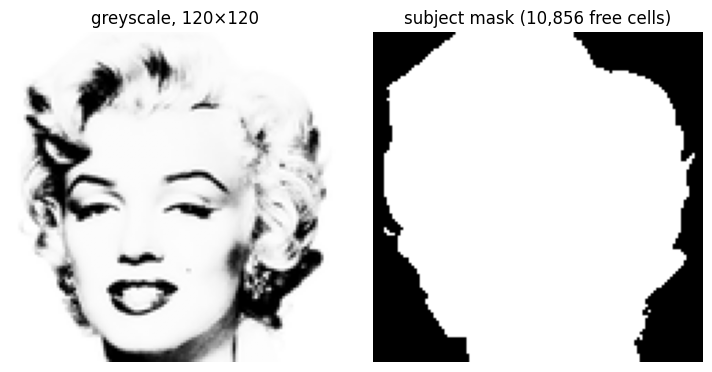

In [2]:
from beyond_tiles.targets import grey_and_mask_from_image

SIZE = 120
grey, free = grey_and_mask_from_image(REPO / "input/images/marilyn.png", SIZE)

fig, axes = plt.subplots(1, 2, figsize=(7.4, 3.7))
axes[0].imshow(grey, cmap="gray")
axes[0].set_title(f"greyscale, {SIZE}×{SIZE}")
axes[1].imshow(free, cmap="gray")
axes[1].set_title(f"subject mask ({int(free.sum()):,} free cells)")
for ax in axes:
    ax.axis("off")
plt.tight_layout()

### Tone mapping: the step that decides the picture

The spike's key debugging lesson: the solver was never the problem, the
*targets* were. This photo is high-key (subject median grey ≈ 234), so a
faithful absolute mapping `density = d_max · (1 − grey/255)` leaves the face
at density ≈ 0.03 — an unrecognisable scatter, even when the solver matches
it perfectly.

The fix mirrors what the tile pipeline does implicitly with its *relative*
density mapping: **histogram-equalize the grey values inside the subject
mask**. The subject's tones then span the full range and its median lands
near density 0.2 — the sweet spot for organic still-life texture.

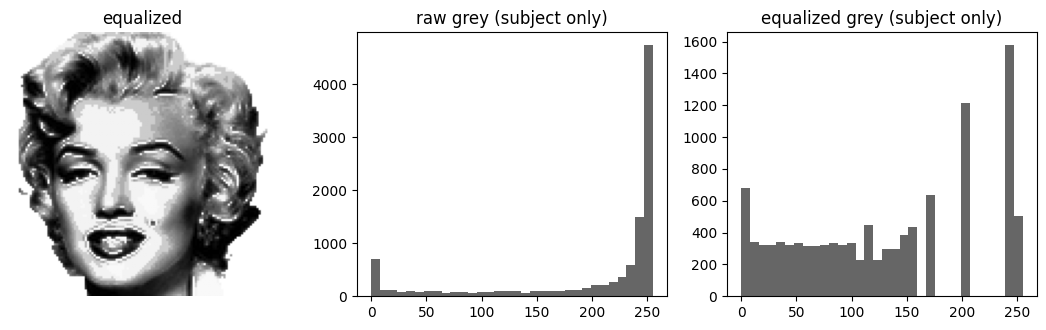

In [3]:
from beyond_tiles.targets import equalize_grey

eq = equalize_grey(grey, free)

fig, axes = plt.subplots(1, 3, figsize=(10.8, 3.4))
axes[0].imshow(eq, cmap="gray")
axes[0].set_title("equalized")
axes[0].axis("off")
axes[1].hist(grey[free], bins=32, color="0.4")
axes[1].set_title("raw grey (subject only)")
axes[2].hist(eq[free], bins=32, color="0.4")
axes[2].set_title("equalized grey (subject only)")
plt.tight_layout()

### Density targets on an 8×8 window grid

Darkness becomes a per-cell target `d = d_max · (1 − grey/255)` with
`d_max = 0.45`: still lifes cannot exceed density ½ asymptotically (Elkies),
and 0.45 leaves the solver room to breathe right below that ceiling.

Per-cell densities are then summed over **disjoint 8×8 windows** into
integer live-cell targets. Disjoint, not overlapping, is the headline
finding of the original spike: with 50%-overlapping windows the same
instance takes 20–50× longer for a *worse* result — the coupling between
overlapping counts, not the still-life structure, is what makes the
optimization hard. Window-to-window smoothness emerges anyway, because
stability constraints reach across window borders.

(If you ever see banding on smooth gradients, `window_targets(...,
dither="fs")` error-diffuses the rounding residuals over the window lattice
instead of rounding each window independently — an option, not the default.)

192 windows with free cells; live-cell targets from 0 to 28


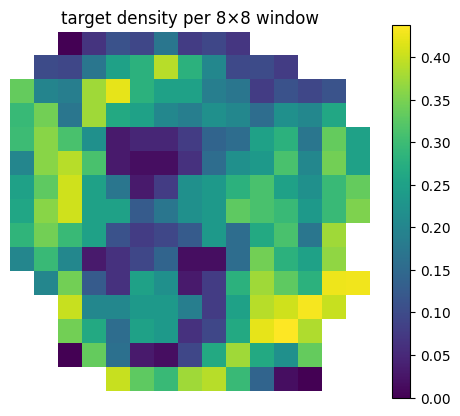

In [4]:
from beyond_tiles.artifacts import _window_field
from beyond_tiles.targets import cell_targets, window_slices, window_targets

D_MAX, K = 0.45, 8
cell_t = cell_targets(eq, d_max=D_MAX)
windows = window_slices(cell_t.shape, k=K, stride=K)
targets, kept = window_targets(cell_t, free, windows)
n_free = np.array([free[si, sj].sum() for si, sj in kept])
print(f"{len(kept)} windows with free cells; "
      f"live-cell targets from {targets.min()} to {targets.max()}")

plt.figure(figsize=(4.8, 4.2))
plt.imshow(_window_field(targets / n_free, kept, eq.shape), cmap="viridis")
plt.title("target density per 8×8 window")
plt.colorbar()
plt.axis("off")
plt.tight_layout()

### The constraint model

One boolean per cell on an (H+2)×(W+2) grid. The border ring is forced dead
**but still carries the no-birth constraint** — without it, a ring cell with
exactly 3 live interior neighbours would come alive in generation 1 and the
"still life" would ripple when opened in Golly.

For every cell, with `S` = sum of its in-grid Moore neighbours:

- **alive ⇒ S ∈ [2, 3]**  (survival)
- **dead ⇒ S ∈ {0,1,2} ∪ {4,…,8}**  (no birth)

both as half-reified linear constraints — CP-SAT handles these natively, no
auxiliary variables. Each kept window `w` gets `dev_w ≥ |Σ cells − t_w|` via
two inequalities, and the objective is `min Σ dev_w`. An all-dead grid is
trivially feasible, so the solver always holds an incumbent and improves it
("anytime" behaviour); with disjoint windows it typically reaches proven
optimality.

In [5]:
from beyond_tiles.still_image import SpikeConfig, solve_image

cfg = SpikeConfig(k=K, stride=K, d_max=D_MAX, time_limit_s=90.0, workers=10, seed=0)
result = solve_image(eq, free, cfg)
print(f"{result.status} | objective {result.objective} | "
      f"{result.wall_time_s:.1f}s | {int(result.pattern.sum()):,} live cells")

OPTIMAL | objective 1 | 21.0s | 2,406 live cells


### Verify: is it really a still life?

Two independent checks: the bounded check embeds the pattern in a one-cell
dead pad and asserts the next generation is identical (this is complete —
nothing outside the pad can influence the interior in one step), and a
toroidal check from the tile-census code path wraps the edges instead.
Passing both is the standard this repo holds every shipped pattern to.

In [6]:
from beyond_tiles.still_image import verify_still_life

verify_still_life(result.pattern)

{'bounded': True, 'toroidal': True}

### Look at it, measure it

Fidelity is measured in density units: **MAD** is the mean absolute
difference between achieved and target window density (lower is better;
0.01 means the average window is off by 1% of its cells). The UGent-colored
render on the right is exactly what produced the shipped PNGs in
[`experiments/beyond_tiles/figures/`](../experiments/beyond_tiles/figures/).

{'mad': 0.0087, 'p95': 0.0212, 'max': 0.3724, 'mad_darkest_quartile': 0.0165, 'pearson': 0.9592, 'n_windows': 192}


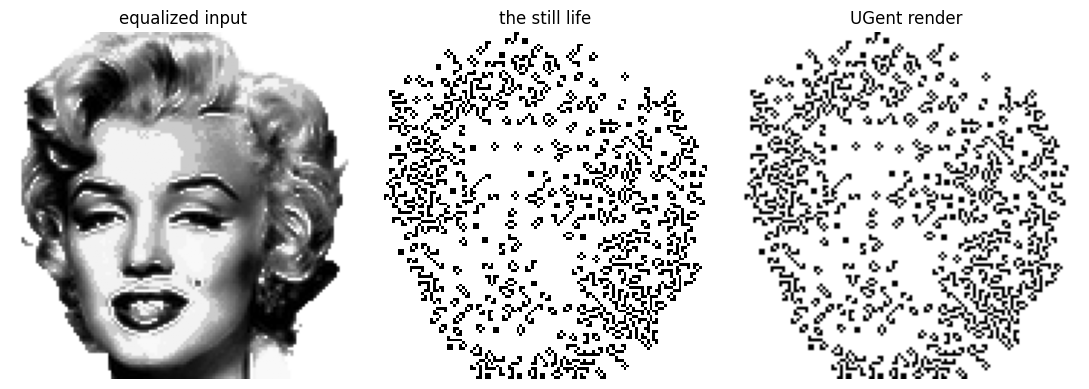

In [7]:
from gol_mosaics import ColorScheme, MosaicRenderer
from beyond_tiles.metrics import deviation_stats

stats = deviation_stats(result.pattern, cell_t, free, kept)
print({k: round(v, 4) for k, v in stats.items()})

render = MosaicRenderer(ColorScheme.ugent()).render_gol_mosaic(result.pattern)
fig, axes = plt.subplots(1, 3, figsize=(11, 4))
axes[0].imshow(eq, cmap="gray")
axes[0].set_title("equalized input")
axes[1].imshow(1 - result.pattern, cmap="gray", interpolation="nearest")
axes[1].set_title("the still life")
axes[2].imshow(np.asarray(render))
axes[2].set_title("UGent render")
for ax in axes:
    ax.axis("off")
plt.tight_layout()

### Export for Golly

`.cells` format via the repo's exporter. Open in Golly and press step —
nothing may move. Any pattern in this notebook can be exported the same
way, including the 1000² one loaded later.

In [8]:
from gol_mosaics.export import GollyExporter

out = REPO / "output/golly/beyond_tiles_demo.cells"
out.parent.mkdir(parents=True, exist_ok=True)
GollyExporter.export_to_cells(result.pattern, str(out))
print("written:", out)

written: /Users/michielrollier/Developer/GitHub/game-of-life-mosaics/output/golly/beyond_tiles_demo.cells


## 2. The optimality wall

You just solved 120² in seconds — so just ask for 400², right? The model
grows only *linearly* in the number of cells; it is **proving optimality**
that explodes:

| Size | Windows | Booleans | Status | Objective (bound) | Wall time | MAD | Peak RAM |
|------|---------|----------|--------|-------------------|-----------|-----|----------|
| 100² | 144   | 10.4 k | OPTIMAL | 0 (0) | 16 s | 0.0086 | 1.2 GB |
| 200² | 509   | 40.8 k | OPTIMAL | 2 (2) | 87 s | 0.0091 | 2.7 GB |
| 400² | 1,968 | 161 k  | FEASIBLE (capped) | 2,874 (2) | 2,404 s | 0.0288 | 4.6 GB |

The big runs ship with the repository as bit-packed `.npz` patterns plus
JSON metric logs in `experiments/beyond_tiles/assets/` — nothing in the
rest of this section runs a solver. The next cell loads the two exhibits
and re-verifies them on the spot.

200²: OPTIMAL, objective 2 (bound 2), 87s, MAD 0.0091, 6,719 live cells, verify {'bounded': True, 'toroidal': True}
400²: FEASIBLE, objective 2874 (bound 2), 2404s, MAD 0.0288, 24,295 live cells, verify {'bounded': True, 'toroidal': True}


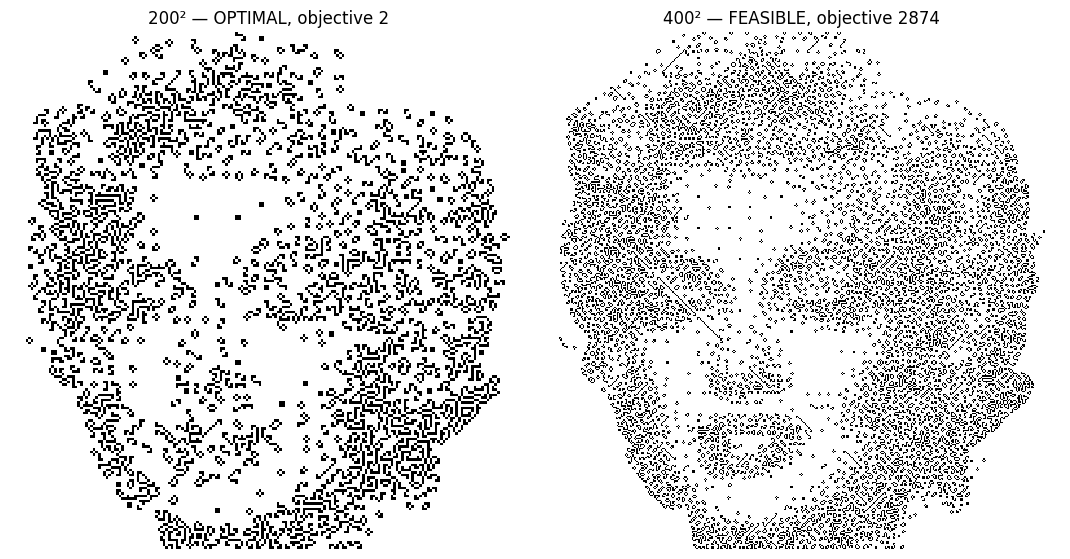

In [9]:
import json

from beyond_tiles.artifacts import ASSETS, load_pattern_asset

shipped = {}
for size, tag in [(200, "optimal"), (400, "feasible")]:
    pat = load_pattern_asset(ASSETS / f"marilyn_{size}_{tag}.npz")
    met = json.loads((ASSETS / f"metrics_{size}.json").read_text())
    shipped[size] = (pat, met)
    print(f"{size}²: {met['status']}, objective {met['objective']} "
          f"(bound {met['best_bound']}), {met['wall_time_s']:.0f}s, "
          f"MAD {met['deviation']['mad']:.4f}, {met['live_cells']:,} live cells, "
          f"verify {verify_still_life(pat)}")

fig, axes = plt.subplots(1, 2, figsize=(10.8, 5.6))
for ax, size in zip(axes, (200, 400)):
    pat, met = shipped[size]
    ax.imshow(1 - pat, cmap="gray", interpolation="nearest")
    ax.set_title(f"{size}² — {met['status']}, objective {met['objective']}")
    ax.axis("off")
plt.tight_layout()

### Watch a 40-minute solve spend its time

The convergence logs tell the story. At 200² the objective collapses to its
proven optimum inside two minutes. At 400² it falls like 1/t and is still
falling when the cap stops it — while the **lower bound sits at 2 the whole
time**. That is not a tuning problem: the stability constraints are
*half-reified* (they only fire when a cell's boolean is committed), so in
the LP relaxation every constraint can be dodged at fractional values and
the root bound is essentially zero. No parameter moves it; the campaign
tried (REPORT.md §5).

The snapshot filmstrip below shows what the solver spends those 40 minutes
on: the structure arrives early, and the rest is shadow density being
poured in one window at a time.

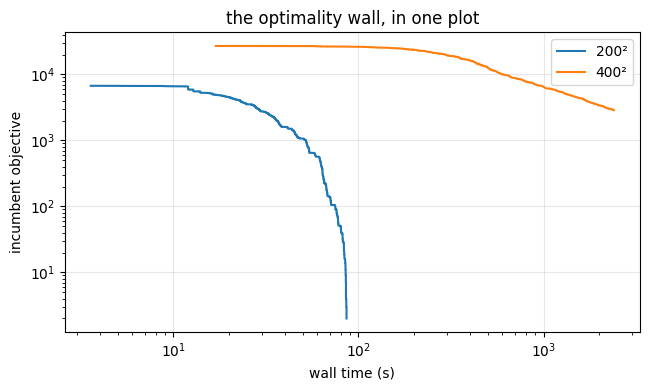

In [10]:
import csv
import gzip

fig, ax = plt.subplots(figsize=(6.6, 4))
for size in (200, 400):
    with gzip.open(ASSETS / f"convergence_{size}.csv.gz", "rt") as f:
        rows = list(csv.DictReader(f))
    ax.plot([float(r["wall_time_s"]) for r in rows],
            [int(r["objective"]) for r in rows],
            drawstyle="steps-post", label=f"{size}²")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("wall time (s)")
ax.set_ylabel("incumbent objective")
ax.set_title("the optimality wall, in one plot")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()

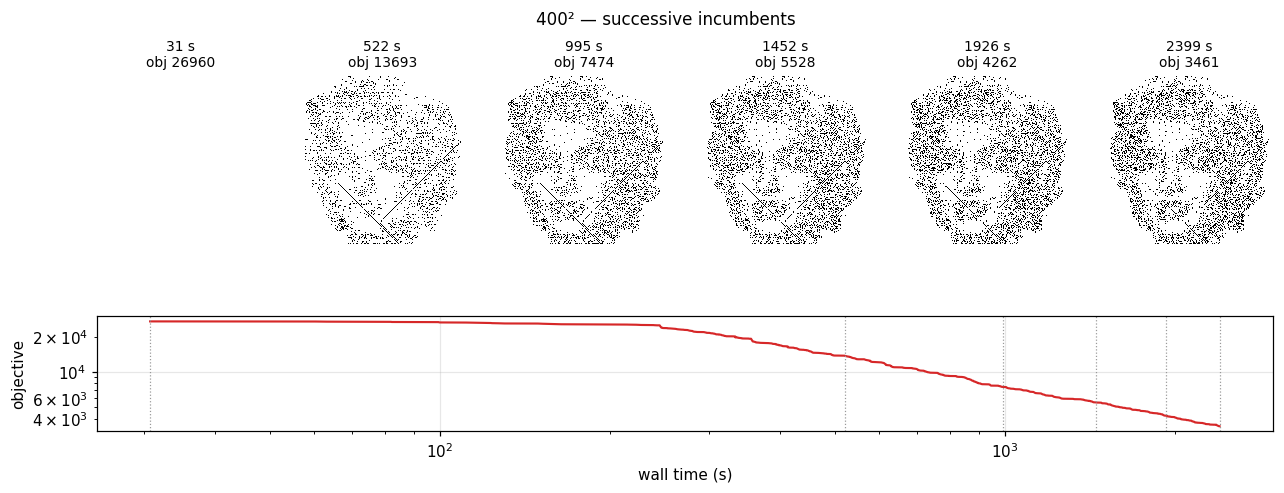

In [11]:
from beyond_tiles.animate import filmstrip
from beyond_tiles.artifacts import load_snapshots

snaps = load_snapshots(ASSETS / "snapshots_400.npz")
with gzip.open(ASSETS / "movie_curve_400.csv.gz", "rt") as f:
    hist = [(float(r["wall_time_s"]), int(r["objective"]))
            for r in csv.DictReader(f)]
filmstrip(snaps, hist, n_frames=6, title="400² — successive incumbents")

So brute force buys a 400² picture, slowly, and the misses concentrate in
the **darkest windows** — targets near the density ceiling, where still
lifes are combinatorially scarcest (darkest-quartile MAD 0.082 vs 0.029
overall). A bigger time limit attacks the flattest part of the curve.

You need better ideas than patience. There are three, and they stack.

## 3. Escape route 1: a still life you can write down

Instead of asking the solver to *find* density, you can construct it: 2×2
blocks (the simplest still life) placed on a lattice with period **3 rows ×
4 columns**. The asymmetric pitch is the whole point. On the tempting
square period-3 lattice, a corner where exactly three of four diagonal
blocks are filled gives the centre dead cell exactly three live neighbours
— a birth, so partial patterns need repair cascades. With the 3×4 pitch
**no dead cell can ever see three live neighbours, no matter which subset
of sites is filled**: every subset is a still life, so subject masks and
per-window occupancy are safe by construction.

The price is a density ceiling of 1/3 instead of the lattice-optimal 4/9 —
the darkest windows keep a deficit of a few cells. The seed's role in the
pipeline is a warm start (`SpikeConfig(hint_mode="agar")`): in the
campaign, the seed alone was worth more than every solver parameter
combined, though strips (next section) still beat seed-then-solve as a
stage 1. The construction itself takes milliseconds:

seed objective 319  |  solver optimum 1  |  all-dead baseline 2,407


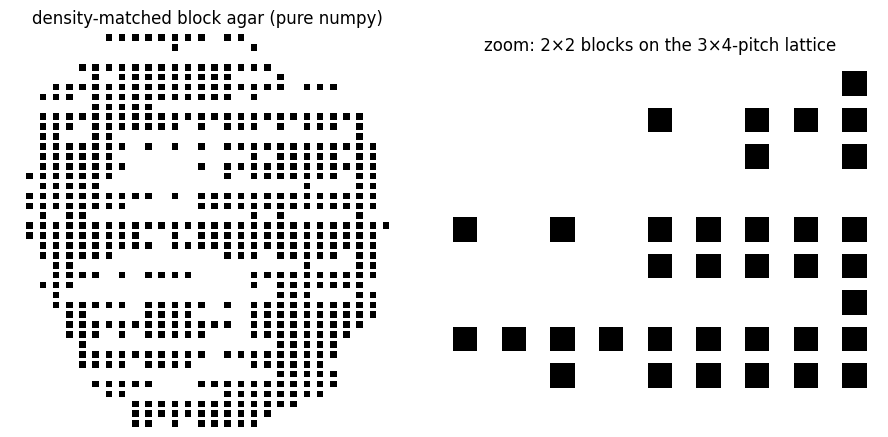

In [12]:
from beyond_tiles.seeds import best_seed

seed, seed_obj = best_seed(free, kept, targets)
print(f"seed objective {seed_obj}  |  solver optimum {result.objective}  |  "
      f"all-dead baseline {int(targets.sum()):,}")

fig, axes = plt.subplots(1, 2, figsize=(9.2, 4.4))
axes[0].imshow(1 - seed, cmap="gray", interpolation="nearest")
axes[0].set_title("density-matched block agar (pure numpy)")
axes[1].imshow(1 - seed[36:64, 40:76], cmap="gray", interpolation="nearest")
axes[1].set_title("zoom: 2×2 blocks on the 3×4-pitch lattice")
for ax in axes:
    ax.axis("off")
plt.tight_layout()

## 4. Escape route 2: cut the canvas into strips

A stability constraint has radius 1. So if you force **two full rows dead**,
the constraints above them depend only on the upper side and the ones below
only on the lower side — the problem splits *exactly* into independent
strips. (One dead row is not enough: a cell in it is checked against only
one side by either strip's model, and 2+1 live neighbours across the cut
could still give birth. `solve_strips` refuses gaps below 2.)

Each 48-row strip solves to **proven optimality in seconds**, strips run in
parallel processes, and the stitched result is a still life by
construction. Strip solving requires the geometry its proofs assume —
disjoint windows aligned to the cuts (`stride == k`), forced-dead masking,
plain rounding — and the code enforces exactly that.

The catch is about to be visible: the gap rows are *forced dead*, and their
windows lose 2 of 8 rows of achievable density. Watch the seams appear.

rows   0- 48: OPTIMAL  objective 0 in 11.2s
rows  48- 96: OPTIMAL  objective 1 in 11.5s
rows  96-120: OPTIMAL  objective 0 in 3.5s
summed strip objective 1  |  against the full-mask targets: 88


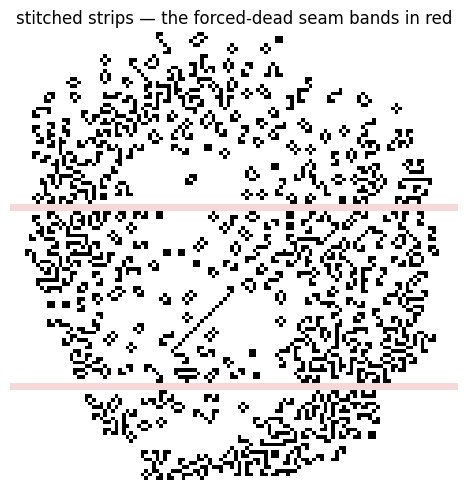

In [13]:
from beyond_tiles.decompose import plan_strips, solve_strips
from beyond_tiles.lns import window_devs

plan = plan_strips(SIZE, K)
scfg = SpikeConfig(k=K, stride=K, d_max=D_MAX, time_limit_s=30.0, workers=3, seed=0)
strips = solve_strips(eq, free, scfg, plan, n_procs=3)

for (r0, r1), st in zip(strips["spans"], strips["per_strip"]):
    print(f"rows {r0:3d}-{r1:3d}: {st['status']:8s} "
          f"objective {st['objective']} in {st['wall_time_s']:.1f}s")
full_obj = int(window_devs(strips["pattern"], free, kept, targets).sum())
print(f"summed strip objective {strips['objective']}  |  "
      f"against the full-mask targets: {full_obj}")

fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(1 - strips["pattern"], cmap="gray", interpolation="nearest")
for r0, r1 in strips["spans"][:-1]:
    ax.axhspan(r1 - plan.gap - 0.5, r1 - 0.5, color="tab:red", alpha=0.18, lw=0)
ax.set_title("stitched strips — the forced-dead seam bands in red")
ax.axis("off")
plt.tight_layout()

Both numbers you just printed are true at once. Each strip is optimal *for
the problem it was asked to solve* — but judged against the full-image
targets, the objective is far larger, and it sits almost entirely in the
windows touching the seam rows: the rows deliberately excluded from every
strip's model.

So the missing piece has one job: repair small regions of an
already-valid still life without breaking it.

## 5. Escape route 3: destroy and repair

Large-neighbourhood search over rectangular patches:

1. **Score** every window-aligned patch by its current deviation; the worst
   patches go first (deviation concentrates in seams and shadows).
2. **Free** a patch's cells and **freeze** everything outside. The frozen
   1-cell collar's stability constraints stay in the patch model with the
   frozen neighbours folded in as constants — so the patch problem is
   *exactly* a sub-problem of the global one.
3. **Re-solve** the patch with CP-SAT for a couple of seconds, hinted with
   the incumbent, and **accept only strict improvements**. Every accepted
   patch is therefore a verified non-worsening move on a pattern that
   remains a still life throughout; the objective history is monotone by
   construction. Disjoint patches (2 cells apart) solve in parallel.
4. Patches that fail to improve go **stale** and are skipped until an
   accepted neighbour changes their context — without this, a few
   high-deviation but locally-optimal dark regions monopolize every round
   (at 1000² this single rule was the difference between polishing to
   objective 11,130 and objective 63).

Crucially, the polisher scores against the **full-mask targets** — the gap
rows count again, so its patches land exactly on the seams and are free to
repopulate them:

objective 88 → 1 in 3 rounds (8/10 patches improved)
verify: {'bounded': True, 'toroidal': True}
MAD 0.0087 (the 120² monolith above: 0.0087)


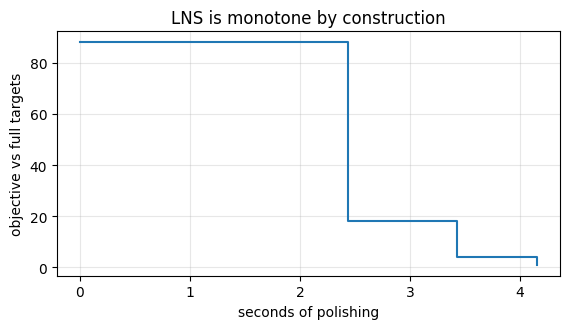

In [14]:
from beyond_tiles.lns import LnsConfig, improve

lcfg = LnsConfig(patch_windows=5, patch_time_s=2.0, budget_s=20.0, n_procs=4, seed=0)
lns_res = improve(strips["pattern"], free, kept, targets, lcfg,
                  log=lambda *a, **k: None)

print(f"objective {full_obj} → {lns_res.objective} in {lns_res.rounds} rounds "
      f"({lns_res.patches_improved}/{lns_res.patches_solved} patches improved)")
print("verify:", verify_still_life(lns_res.pattern))
print(f"MAD {deviation_stats(lns_res.pattern, cell_t, free, kept)['mad']:.4f} "
      f"(the 120² monolith above: {stats['mad']:.4f})")

t, obj = zip(*lns_res.obj_history)
plt.figure(figsize=(5.8, 3.4))
plt.step(t, obj, where="post")
plt.xlabel("seconds of polishing")
plt.ylabel("objective vs full targets")
plt.title("LNS is monotone by construction")
plt.grid(alpha=0.3)
plt.tight_layout()

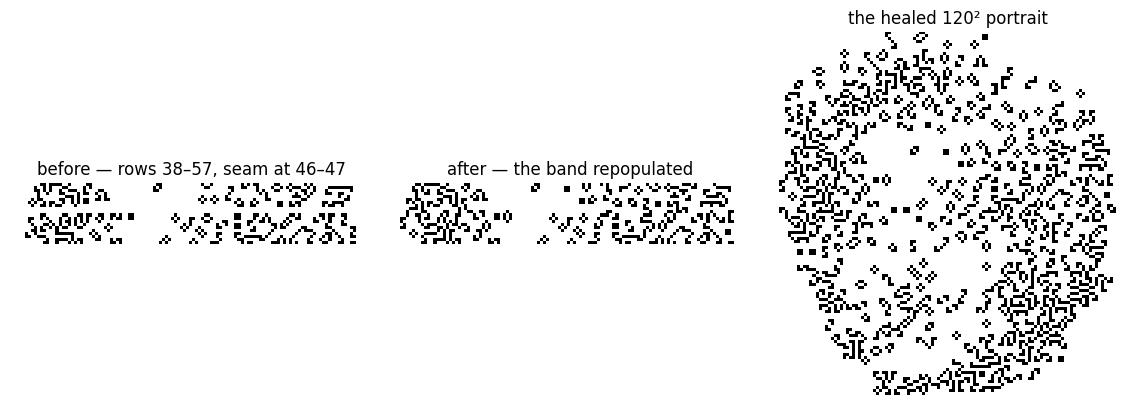

In [15]:
band = slice(38, 58)
fig, axes = plt.subplots(1, 3, figsize=(11.5, 4.2))
axes[0].imshow(1 - strips["pattern"][band], cmap="gray", interpolation="nearest")
axes[0].set_title("before — rows 38–57, seam at 46–47")
axes[1].imshow(1 - lns_res.pattern[band], cmap="gray", interpolation="nearest")
axes[1].set_title("after — the band repopulated")
axes[2].imshow(1 - lns_res.pattern, cmap="gray", interpolation="nearest")
axes[2].set_title("the healed 120² portrait")
for ax in axes:
    ax.axis("off")
plt.tight_layout()

### What you just ran

Strips for provable structure, LNS for the seams and the shadows — that
**is** the champion pipeline, in miniature. At full scale it is one
command:

```bash
python experiments/beyond_tiles/run_experiment.py e9 --size 400 --mode solve \
    --time 120 --lns-polish 300
```

which writes the stitched pattern, the polish log and a render under
`experiments/beyond_tiles/results/e9/`.

## 6. The same recipe at 400² and 1000²

The shipped 400² pipeline run: nine 48-row strips, **all nine proven
optimal**, stitched and polished for another minute. Under three minutes of
wall time end to end, against forty minutes for the monolithic solve — with
four times better density fidelity, and an objective within 1 of the only
lower bound ever proven for this instance. Every number in the figure and
the scoreboard below is read from the committed JSON logs at render time.

run                 wall  objective      MAD  dark-q MAD  Pearson
monolith 400²      2404s      2,874   0.0288      0.0816   0.9233
pipeline 400²       177s          3   0.0067      0.0071   0.9852
pipeline 1000²      791s         63   0.0048      0.0045   0.9964


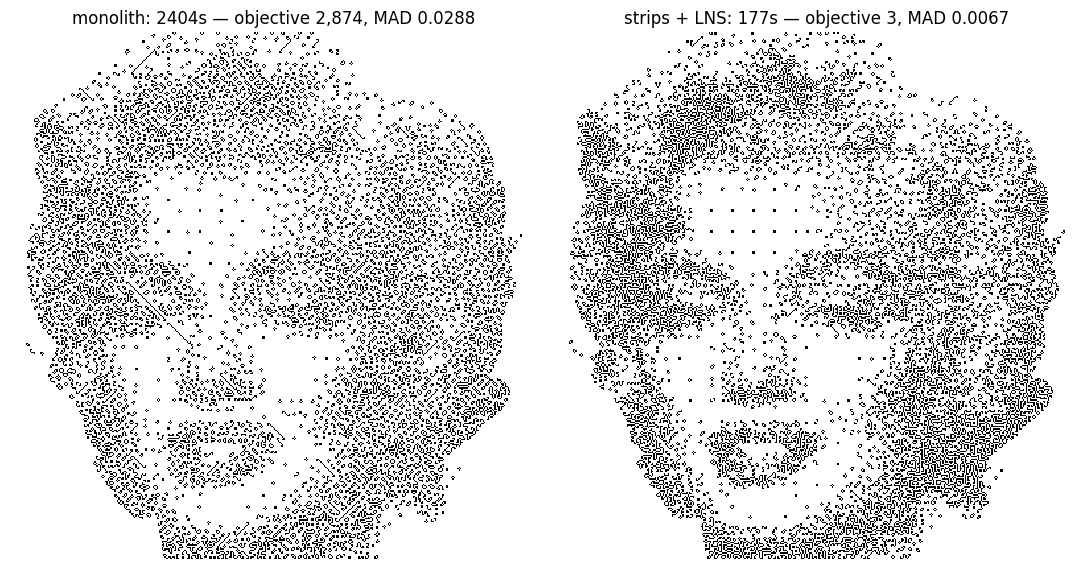

In [16]:
pipe400 = load_pattern_asset(ASSETS / "marilyn_400_pipeline.npz")
rep400 = json.loads((ASSETS / "pipeline_400.json").read_text())
rep1000 = json.loads((ASSETS / "pipeline_1000.json").read_text())
pat400, met400 = shipped[400]

s4, l4 = rep400["solve"], rep400["lns"]
wall4 = s4["wall_time_s"] + l4["wall_time_s"]

fig, axes = plt.subplots(1, 2, figsize=(11, 5.8))
axes[0].imshow(1 - pat400, cmap="gray", interpolation="nearest")
axes[0].set_title(f"monolith: {met400['wall_time_s']:.0f}s — objective "
                  f"{met400['objective']:,}, MAD {met400['deviation']['mad']:.4f}")
axes[1].imshow(1 - pipe400, cmap="gray", interpolation="nearest")
axes[1].set_title(f"strips + LNS: {wall4:.0f}s — objective {l4['objective']}, "
                  f"MAD {l4['deviation_vs_full_targets']['mad']:.4f}")
for ax in axes:
    ax.axis("off")
plt.tight_layout()

l10 = rep1000["lns"]
rows = [
    ("monolith 400²", met400["wall_time_s"], met400["objective"],
     met400["deviation"]),
    ("pipeline 400²", wall4, l4["objective"], l4["deviation_vs_full_targets"]),
    ("pipeline 1000²", rep1000["solve"]["wall_time_s"] + l10["wall_time_s"],
     l10["objective"], l10["deviation_vs_full_targets"]),
]
print(f"{'run':16s}{'wall':>8s}{'objective':>11s}{'MAD':>9s}"
      f"{'dark-q MAD':>12s}{'Pearson':>9s}")
for name, w, o, dev in rows:
    print(f"{name:16s}{w:7.0f}s{o:11,d}{dev['mad']:9.4f}"
          f"{dev['mad_darkest_quartile']:12.4f}{dev['pearson']:9.4f}")

The pipeline earned its place in an A/B campaign whose full tables live in
REPORT.md §5. The short version of what *lost*: solver parameters cannot
move a structurally-stuck bound; seed-then-solve (route 1 as a warm start)
halves the monolith's gap but still loses to strips as a first stage; and a
33-million-updates-per-second simulated annealer was an honest negative —
it converges to block packings, so more throughput just reaches the wrong
answer sooner.

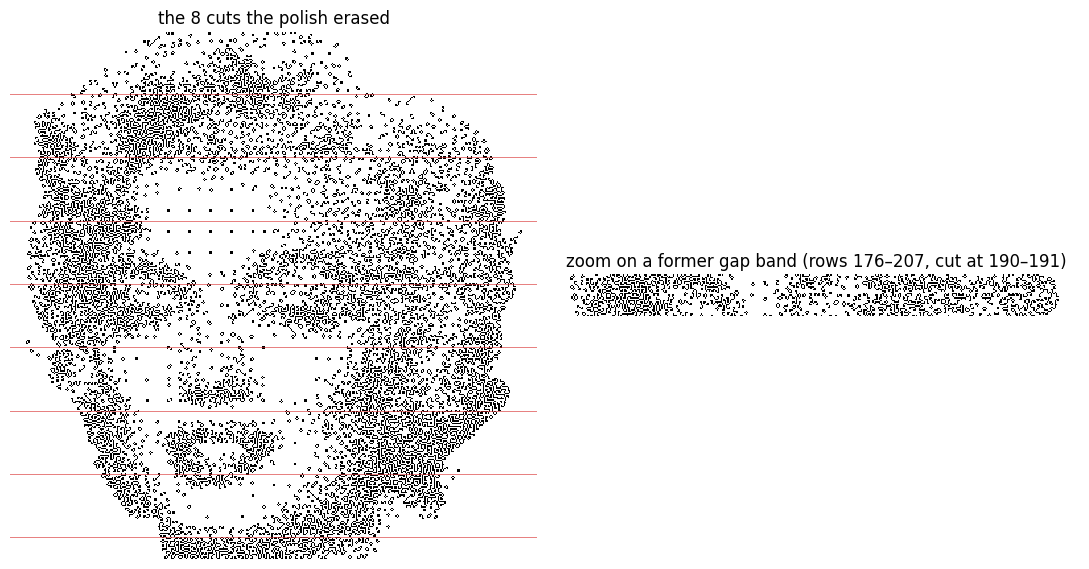

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5.8))
axes[0].imshow(1 - pipe400, cmap="gray", interpolation="nearest")
for r0, r1 in rep400["plan"]["spans"][:-1]:
    axes[0].axhline(r1 - 1, color="tab:red", lw=0.7, alpha=0.6)
axes[0].set_title("the 8 cuts the polish erased")
zoom = slice(176, 208)
axes[1].imshow(1 - pipe400[zoom], cmap="gray", interpolation="nearest")
axes[1].set_title("zoom on a former gap band (rows 176–207, cut at 190–191)")
for ax in axes:
    ax.axis("off")
plt.tight_layout()

### 1000²: past the memory wall

At 1000² the monolithic model does not even fit in this machine's 16 GB —
the 400² solve already peaked at 4.6 GB. Strips change the game entirely:
per-strip memory is constant in canvas height, the strips are
embarrassingly parallel, and the polisher never holds more than a few
40×40-cell sub-models. Scale is now bounded by patience, not by RAM.

21 strips: objective 229 in 301s wall (5029s CPU)
LNS polish: objective 63 after 127 rounds, 490s, MAD 0.0048
169,089 live cells | verify {'bounded': True, 'toroidal': True}


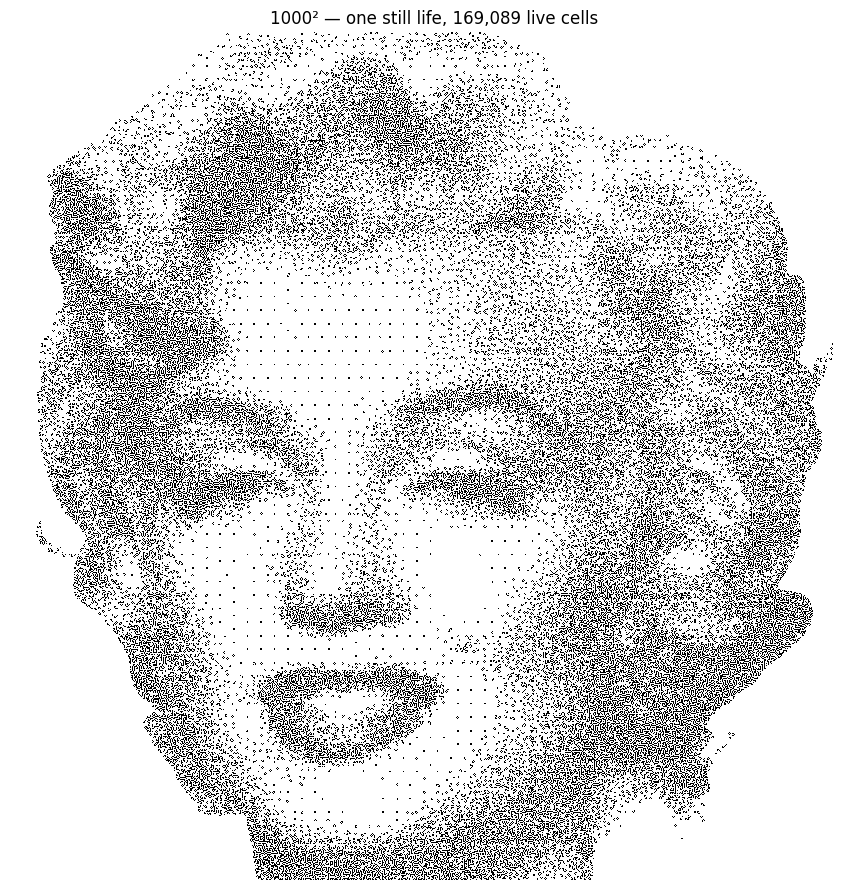

In [18]:
pipe1000 = load_pattern_asset(ASSETS / "marilyn_1000_pipeline.npz")
s10 = rep1000["solve"]
print(f"{len(rep1000['plan']['spans'])} strips: objective {s10['objective']} "
      f"in {s10['wall_time_s']:.0f}s wall ({s10['total_cpu_s']:.0f}s CPU)")
print(f"LNS polish: objective {l10['objective']} after {l10['rounds']} rounds, "
      f"{l10['wall_time_s']:.0f}s, MAD {l10['deviation_vs_full_targets']['mad']:.4f}")
print(f"{int(pipe1000.sum()):,} live cells | verify {verify_still_life(pipe1000)}")

plt.figure(figsize=(9, 9))
plt.imshow(1 - pipe1000, cmap="gray", interpolation="nearest")
plt.title(f"1000² — one still life, {int(pipe1000.sum()):,} live cells")
plt.axis("off")
plt.tight_layout()

## 7. What resolution buys

The same patch of face at four scales. The vocabulary never changes — the
same blocks, boats, snakes and ad-hoc still lifes everywhere — what changes
is how much of it fits inside a lip edge. At 120² a facial feature is a
handful of objects; at 1000² it is a *texture*.

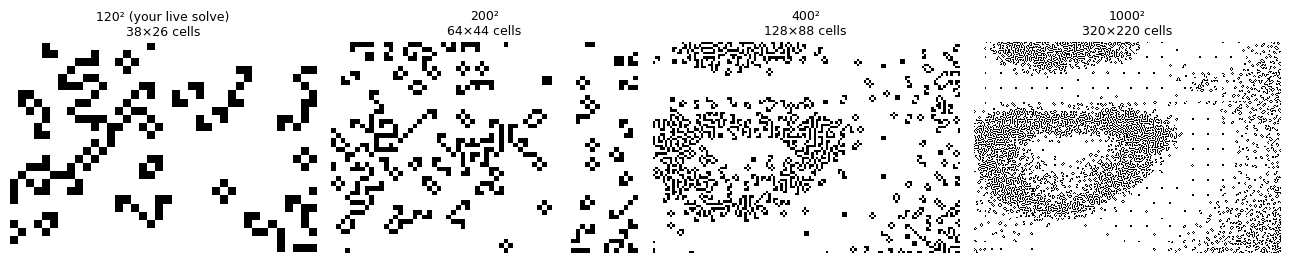

In [19]:
BOX = (0.68, 0.90, 0.30, 0.62)  # row0, row1, col0, col1 as canvas fractions
panels = [("120² (your live solve)", lns_res.pattern),
          ("200²", shipped[200][0]),
          ("400²", pipe400),
          ("1000²", pipe1000)]

fig, axes = plt.subplots(1, 4, figsize=(13, 3.9))
for ax, (label, pat) in zip(axes, panels):
    n = pat.shape[0]
    r0, r1, c0, c1 = (int(round(f * n)) for f in BOX)
    crop = pat[r0:r1, c0:c1]
    ax.imshow(1 - crop, cmap="gray", interpolation="nearest")
    ax.set_title(f"{label}\n{crop.shape[1]}×{crop.shape[0]} cells", fontsize=9)
    ax.axis("off")
plt.tight_layout()

## 8. Run it on your own image

Any photo with an alpha-cut subject works — `grey_and_mask_from_image` will
call `rembg` automatically if the background is still there (install the
`preprocessing` extra for that). The knobs that matter:

- **size** — any multiple of 8. Up to ~200², plain `solve_image` proves
  optimality in seconds to minutes; from ~300² up, use strips + LNS.
- **`seed`** — the variation knob: same image, same quality, different
  pattern.
- **`d_max`** — 0.45 for light images; drop to **0.40 for dark, low-key
  photos**, whose equalized targets otherwise pile up on the still-life
  packing ceiling where the solver can no longer follow (REPORT.md §5 C8).
- **`patch_time_s`** — 2 s per LNS patch is enough for light images; dense
  dark regions need ~10 s per patch, and several polish rounds.
- **`dither="fs"`** — error-diffused window targets, for smooth synthetic
  gradients (strip solving requires plain rounding and enforces it).
- **`slack`** — per-window tolerance in cells; only worth it for monolithic
  solves of large canvases (REPORT.md §5 C3).

The CLI (`python experiments/beyond_tiles/run_experiment.py <cmd>`) drives
the same code and writes complete run directories (pattern, renders,
convergence log, metrics, Golly file) under `experiments/beyond_tiles/results/`:

| command | what it does |
|---|---|
| `e2 --size 200 --time 300` | monolithic solve of the demo image, full artifact dir |
| `e9 --size 400 --mode solve --time 120 --lns-polish 300` | the champion pipeline |
| `lns RUN_DIR --budget 600` | polish any saved run in place |
| `e6` / `gif RUN_DIR` | convergence movies (how the snapshots above were made) |
| `verify RUN_DIR` | recheck a saved pattern; exits 1 on failure |
| `bench --suite quick --tag NAME` | the A/B harness the campaign was run on |

Those demo subcommands are wired to the Marilyn source. For **your own
photo at any rectangular size**, use `poster.py` — the general form of the
pipeline, with the dark-image defaults baked in. It produced the 1416×2000
John Conway poster in `figures/john_1416x2000_pipeline.png` (MAD 0.0063,
verified; the full story is REPORT.md §5 C8):

```bash
python experiments/beyond_tiles/poster.py input/images/john.png \
    --width 1416 --height 2000 --out results/john
```

The guarded cell below is the same pipeline as a Python recipe — flip the
flag to run it (a 304² canvas takes a few minutes):

In [20]:
RUN_MY_IMAGE = False  # flip to True to run (~2-5 min at 304²)

if RUN_MY_IMAGE:
    MY_IMAGE = REPO / "input/images/marilyn.png"  # <- your photo here
    MY_SIZE = 304                                 # any multiple of 8

    my_grey, my_free = grey_and_mask_from_image(MY_IMAGE, MY_SIZE)
    my_eq = equalize_grey(my_grey, my_free)

    my_cfg = SpikeConfig(k=8, stride=8, d_max=0.45,
                         time_limit_s=120.0, workers=2, seed=0)
    my_strips = solve_strips(my_eq, my_free, my_cfg,
                             plan_strips(MY_SIZE, 8), n_procs=4)

    my_ct = cell_targets(my_eq, d_max=0.45)
    my_windows = window_slices(my_ct.shape, k=8, stride=8)
    my_targets, my_kept = window_targets(my_ct, my_free, my_windows)
    polished = improve(my_strips["pattern"], my_free, my_kept, my_targets,
                       LnsConfig(budget_s=120.0))

    print("verify:", verify_still_life(polished.pattern))
    GollyExporter.export_to_cells(
        polished.pattern, str(REPO / "output/golly/my_still_life.cells"))

## 9. Where to go next

- [`experiments/beyond_tiles/REPORT.md`](../experiments/beyond_tiles/REPORT.md)
  is the data appendix: the original feasibility experiments E1–E6
  (including the texture census that puts "beyond tiles" on a number — a
  ~6.6-bit motif-entropy gap over the tile mosaic) and the full
  optimization campaign §5 with every A/B table, the annealer post-mortem
  and the considered-and-rejected list.
- Open problems: a non-vacuous lower bound for the reified model, period-2
  oscillators as "shimmering" mosaics, and aesthetic constraints (forbid
  the boring blinker-adjacent packings) — none of which the pipeline needs,
  all of which it makes reachable.
- Everything here runs from a clean clone with
  `pip install -e ".[beyond]"`. The demo image solve at the top takes
  seconds; the 1000² flagship you scrolled past took thirteen minutes on a
  laptop.